# SRMS Candidate Anomaly Detection MVP

## 1. Project introduction

This notebook presents an **MVP workflow for SRMS candidate anomaly detection** using real QC data from `ResultSet.csv`.

The purpose of the notebook is to demonstrate a working end-to-end process that can:
- identify a practical SRMS candidate subset from the available real dataset
- analyse those records using QC rules and machine learning
- assign anomaly and risk outputs
- provide tables, charts, and exported files that can support review and discussion

A key point is that the available export does **not** contain an explicit `SRMS` label. Based on Datamine's clarification, SRMS, CRM, LCS, and similar materials are all assessed as **Standards** against assigned target values and upper/lower limits. For that reason, this notebook extracts a real reference-material standard subset and treats it as the best available **SRMS candidate subset** for MVP analysis.


## Assumptions

This notebook is based on the following assumptions:

- `ResultSet.csv` is a **real QC data export** from the working environment.
- The file does **not explicitly label SRMS** as a separate subtype.
- In line with Datamine's clarification, SRMS-like materials are assessed using the same core logic as **Standards**.
- A practical SRMS candidate subset can therefore be extracted from real `Standard` records that have:
  - reference-material codes
  - assigned target values
  - assigned lower and upper limits
- This approach is suitable for an **MVP workflow**, but it is not the same as having a fully confirmed SRMS-labelled dataset.

- CCLAS limit inclusivity flags are retained in the results as `LowerLimitInclusive`, `UpperLimitInclusive`, `WarningLowerInclusive`, and `WarningUpperInclusive` so reviewers can tell whether limits are inclusive or exclusive.
- `PRECISION_STATUS` is excluded from the SRMS candidate results because it is not applicable to Standards, Blanks, or Spikes.
- Known supplied-source correction applied: `GE_ICP40Q12 / OREAS_351 / ZN / MG_KG` target values of `46.99` are corrected to `469900`.


## User value

From a user perspective, this MVP is designed to answer a simple question:

**If we upload real QC data, can the system return a useful SRMS-style anomaly assessment?**

In its current form, the notebook provides:
- a real-data extraction step for SRMS candidate records
- rule-based QC assessment
- machine learning anomaly detection using Isolation Forest
- risk scoring to prioritise review
- summary outputs and visualisations that help explain what the workflow is doing

This means the notebook is not only a technical experiment. It also demonstrates the core value of a possible future workflow where uploaded QC data is analysed and returned as a clear, reviewable assessment.


In [1]:
from pathlib import Path
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

plt.style.use('default')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

PROJECT_DIR = Path('/Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp')
SOURCE_PATH = Path('/Users/linhlinh/Downloads/ResultSet.csv')
OUTPUT_DIR = PROJECT_DIR / 'srms_outputs'
RESULTS_CSV = PROJECT_DIR / 'srms_candidate_anomaly_results.csv'
SUMMARY_CSV = PROJECT_DIR / 'srms_candidate_summary.csv'
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_VERSION = 'srms-iforest-v0.1'
RULE_VERSION = 'qc-rules-v0.1'


Libraries loaded successfully.


## 2. Data loading and SRMS candidate extraction

The starting file is the real `ResultSet.csv` export. To build an SRMS-focused subset, the notebook filters for:
- `ANALYTICAL_TYPE = Standard`
- rows with a reference material code rather than `Sample` or `TSV_BLANK`
- rows with target values and lower/upper limits

This is an **SRMS candidate extract**, not a perfectly labelled SRMS dataset. The reason for this choice is that the real file contains the right standard-style QC structure, but not an explicit SRMS subtype field.


In [2]:
REQUIRED_COLUMNS = [
    'ANALYTICAL_TYPE', 'STD_LOT_CODE', 'STD_CODE', 'JOB_CODE',
    'NUMERIC_FINAL_VALUE', 'ANALYSED_DATE', 'SCHEME_CODE', 'ANALYTE_CODE',
    'STANDARD_STATUS', 'PRECISION_STATUS', 'INTERNAL_MIN_VALUE', 'INTERNAL_MAX_VALUE',
    'INTERNAL_MIN_INCLUSIVE', 'INTERNAL_MAX_INCLUSIVE',
    'INTERNAL_MIN_WARNING_VALUE', 'INTERNAL_MAX_WARNING_VALUE',
    'INTERNAL_MIN_WARNING_INCLUSIVE', 'INTERNAL_MAX_WARNING_INCLUSIVE',
    'INTERNAL_TARGET_VALUE', 'PARENT_NUMERIC_FINAL_VALUE',
    'SPECIFICATION_CODE', 'UNIT_CODE'
]

source_path = SOURCE_PATH
raw = pd.read_csv(source_path, low_memory=False)
missing_columns = [column for column in REQUIRED_COLUMNS if column not in raw.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

raw['ANALYSED_DATE'] = pd.to_datetime(raw['ANALYSED_DATE'], errors='coerce')
print('Real source file:', source_path)
print('Total rows in ResultSet.csv:', len(raw))


Real source file: /Users/linhlinh/Downloads/ResultSet.csv
Total rows in ResultSet.csv: 99999


In [3]:
def extract_srms_candidates(raw_df: pd.DataFrame) -> pd.DataFrame:
    standard_mask = raw_df['ANALYTICAL_TYPE'].eq('Standard')
    reference_mask = ~raw_df['STD_CODE'].fillna('').isin(['', 'Sample', 'TSV_BLANK'])
    target_mask = raw_df['INTERNAL_TARGET_VALUE'].notna()
    limit_mask = raw_df['INTERNAL_MIN_VALUE'].notna() & raw_df['INTERNAL_MAX_VALUE'].notna()

    extracted = raw_df.loc[standard_mask & reference_mask & target_mask & limit_mask].copy()
    extracted = extracted.rename(columns={
        'STD_CODE': 'SRMSStandardCode',
        'STD_LOT_CODE': 'SRMSLotCode',
        'JOB_CODE': 'JobCode',
        'NUMERIC_FINAL_VALUE': 'Value',
        'ANALYSED_DATE': 'AnalysisDate',
        'SCHEME_CODE': 'SchemeCode',
        'ANALYTE_CODE': 'Analyte',
        'STANDARD_STATUS': 'StandardStatus',
        'INTERNAL_MIN_VALUE': 'LowerLimit',
        'INTERNAL_MIN_INCLUSIVE': 'LowerLimitInclusive',
        'INTERNAL_MAX_VALUE': 'UpperLimit',
        'INTERNAL_MAX_INCLUSIVE': 'UpperLimitInclusive',
        'INTERNAL_MIN_WARNING_VALUE': 'WarningLower',
        'INTERNAL_MIN_WARNING_INCLUSIVE': 'WarningLowerInclusive',
        'INTERNAL_MAX_WARNING_VALUE': 'WarningUpper',
        'INTERNAL_MAX_WARNING_INCLUSIVE': 'WarningUpperInclusive',
        'INTERNAL_TARGET_VALUE': 'TargetValue',
        'PARENT_NUMERIC_FINAL_VALUE': 'ParentValue',
        'UNIT_CODE': 'UnitCode',
        'SPECIFICATION_CODE': 'SpecificationCode',
    })
    extracted['SampleID'] = extracted['JobCode'].fillna('JOB-UNKNOWN') + '-' + extracted.index.astype(str)
    extracted['SourceCategory'] = 'Standard'
    extracted['SRMSAssumption'] = (
        'Reference-material standard used as SRMS candidate because explicit SRMS subtype '
        'is not present in ResultSet.csv.'
    )
    extracted = extracted.drop(columns=['PRECISION_STATUS', 'PrecisionStatus'], errors='ignore')
    return extracted.sort_values('AnalysisDate').reset_index(drop=True)


def apply_known_source_corrections(df: pd.DataFrame) -> pd.DataFrame:
    corrected = df.copy()
    oreas_351_zinc_mask = (
        corrected['SchemeCode'].eq('GE_ICP40Q12')
        & corrected['SRMSLotCode'].eq('OREAS_351')
        & corrected['SRMSStandardCode'].eq('OREAS_351')
        & corrected['Analyte'].eq('ZN')
        & corrected['UnitCode'].eq('MG_KG')
        & corrected['TargetValue'].eq(46.99)
    )
    corrected.loc[oreas_351_zinc_mask, 'TargetValue'] = 469900
    return corrected


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    working = df.copy()
    working['Deviation'] = working['Value'] - working['TargetValue']
    safe_target = working['TargetValue'].replace(0, np.nan)
    working['DeviationPct'] = ((working['Deviation'] / safe_target) * 100).replace([np.inf, -np.inf], np.nan).fillna(0)
    working['RollingMean'] = working.groupby(['SRMSStandardCode', 'Analyte'])['Value'].transform(
        lambda s: s.rolling(window=5, min_periods=1).mean()
    )
    working['RollingStd'] = working.groupby(['SRMSStandardCode', 'Analyte'])['Value'].transform(
        lambda s: s.rolling(window=5, min_periods=2).std()
    ).fillna(0)
    working['DistanceToLower'] = working['Value'] - working['LowerLimit']
    working['DistanceToUpper'] = working['UpperLimit'] - working['Value']
    working['LimitSpan'] = working['UpperLimit'] - working['LowerLimit']
    working['WithinRangePct'] = np.where(
        working['LimitSpan'].abs() > 1e-9,
        (working['Value'] - working['LowerLimit']) / working['LimitSpan'] * 100,
        np.nan,
    )
    return working


def add_rule_flags(df: pd.DataFrame) -> pd.DataFrame:
    working = df.copy()
    working['WarningLower'] = working['WarningLower'].fillna(working['LowerLimit'] + working['LimitSpan'] * 0.10)
    working['WarningUpper'] = working['WarningUpper'].fillna(working['UpperLimit'] - working['LimitSpan'] * 0.10)

    lower_inclusive = working['LowerLimitInclusive'].fillna('Y').eq('Y')
    upper_inclusive = working['UpperLimitInclusive'].fillna('Y').eq('Y')
    warning_lower_inclusive = working['WarningLowerInclusive'].fillna('Y').eq('Y')
    warning_upper_inclusive = working['WarningUpperInclusive'].fillna('Y').eq('Y')

    lower_breach = np.where(lower_inclusive, working['Value'] < working['LowerLimit'], working['Value'] <= working['LowerLimit'])
    upper_breach = np.where(upper_inclusive, working['Value'] > working['UpperLimit'], working['Value'] >= working['UpperLimit'])
    warning_lower_breach = np.where(warning_lower_inclusive, working['Value'] < working['WarningLower'], working['Value'] <= working['WarningLower'])
    warning_upper_breach = np.where(warning_upper_inclusive, working['Value'] > working['WarningUpper'], working['Value'] >= working['WarningUpper'])

    limit_red = lower_breach | upper_breach
    warning_yellow = warning_lower_breach | warning_upper_breach
    status_red = working['StandardStatus'].fillna('').str.contains('Failure', case=False)
    status_yellow = working['StandardStatus'].fillna('').str.contains('Warning', case=False)

    working['RuleFlag'] = np.select([limit_red | status_red, warning_yellow | status_yellow], ['Red', 'Yellow'], default='Green')
    working['RuleFlagScore'] = working['RuleFlag'].map({'Green': 0, 'Yellow': 1, 'Red': 2}).astype(int)
    return working


def add_ml_scores(df: pd.DataFrame) -> pd.DataFrame:
    working = df.copy()
    features = [
        'Value', 'TargetValue', 'Deviation', 'DeviationPct', 'RollingMean', 'RollingStd',
        'DistanceToLower', 'DistanceToUpper', 'LimitSpan', 'WithinRangePct', 'RuleFlagScore'
    ]
    frame = working[features].replace([np.inf, -np.inf], np.nan)
    for column in features:
        frame[column] = frame[column].fillna(frame[column].median()).fillna(0)

    model = IsolationForest(n_estimators=250, contamination=0.05, random_state=42, n_jobs=-1)
    labels = model.fit_predict(frame)
    scores = -model.score_samples(frame)
    working['IForestAnomaly'] = labels == -1
    working['IForestScore'] = scores
    working['IForestScoreNorm'] = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return working


def add_risk(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    working = df.copy()
    std_scale = max(float(working['RollingStd'].std()), 1.0)
    deviation_component = np.clip(working['DeviationPct'].abs(), 0, 50) / 50 * 35
    variability_component = np.clip(working['RollingStd'] / std_scale, 0, 3) / 3 * 20
    range_component = np.where(working['RuleFlag'].eq('Red'), 20, np.where(working['RuleFlag'].eq('Yellow'), 10, 0))
    model_component = working['IForestScoreNorm'] * 25
    working['RiskScore'] = (deviation_component + variability_component + range_component + model_component).round(2)
    working['RiskLevel'] = pd.cut(working['RiskScore'], bins=[-0.01, 30, 60, 100], labels=['Low', 'Medium', 'High'])
    working['ModelVersion'] = MODEL_VERSION
    working['RuleVersion'] = RULE_VERSION

    summary = working['RiskLevel'].value_counts().rename_axis('RiskLevel').reset_index(name='Count')
    summary['Percent'] = (summary['Count'] / len(working) * 100).round(2)
    summary['RiskLevel'] = pd.Categorical(summary['RiskLevel'], categories=['Low', 'Medium', 'High'], ordered=True)
    summary = summary.sort_values('RiskLevel').reset_index(drop=True)
    return working, summary

srms_df = apply_known_source_corrections(extract_srms_candidates(raw))
featured = add_features(srms_df)
ruled = add_rule_flags(featured)
modelled = add_ml_scores(ruled)
results, risk_summary = add_risk(modelled)

print(f'SRMS candidate rows extracted: {len(results)}')
print('Source analytical type used: Standard')
print('Extraction rule: reference-material standards with targets and limits.')
results.head(10)


SRMS candidate rows extracted: 36442
Source analytical type used: Standard
Extraction rule: reference-material standards with targets and limits.


0        Standard  OREAS_501C        OREAS_501C  TSV_LB0002628992    0.259341 2020-06-26 02:40:42  GE_IMS40Q12      TE           Pass             NaN    0.100000    0.400000      0.345150      0.154850         0.25          NaN    MG_KG        OREAS_501C  TSV_LB0002628992-99997       Standard  Reference-material standard used as SRMS candidate because explicit SRMS subtype is not present in ResultSet.csv.   0.009341      3.736264     0.259341         0.0         0.159341         0.140659   0.300000       53.113553    Green              0           False      0.311295          0.000930       2.64       Low
1        Standard  OREAS_501C        OREAS_501C  TSV_LB0002628992   24.835165 2020-06-26 02:40:42  GE_IMS40Q12      AS           Pass             NaN   21.010490   26.789510     25.733130     22.066870        23.90          NaN    MG_KG        OREAS_501C  TSV_LB0002628992-99994       Standard  Reference-material standard used as SRMS candidate because explicit SRMS subtype is not present in ResultSet.csv.   0.935165      3.912824    24.835165         0.0         3.824675         1.954345   5.779020       66.182066    Green              0           False      0.317261          0.012208       3.04       Low
2        Standard  OREAS_501C        OREAS_501C  TSV_LB0002628992    0.675824 2020-06-26 02:40:42  GE_IMS40Q12      BI           Pass             NaN    0.521019    0.858981      0.797157      0.582843         0.69          NaN    MG_KG        OREAS_501C  TSV_LB0002628992-99996       Standard  Reference-material standard used as SRMS candidate because explicit SRMS subtype is not present in ResultSet.csv.  -0.014176     -2.054467     0.675824         0.0         0.154805         0.183157   0.337962       45.805498    Green              0           False      0.311687          0.001671       1.48       Low
3        Standard  OREAS_501C        OREAS_501C  TSV_LB0002628992    2.263736 2020-06-26 02:40:42  GE_IMS40Q12      SE           Pass             NaN   -3.137085    7.277085      5.372892     -1.232892         2.07          NaN    MG_KG        OREAS_501C  TSV_LB0002628992-99995       Standard  Reference-material standard used as SRMS candidate because explicit SRMS subtype is not present in ResultSet.csv.   0.193736      9.359240     2.263736         0.0         5.400821         5.013349  10.414170       51.860314    Green              0           False      0.314256          0.006527       6.71       Low
4        Standard   OREAS_624         OREAS_624  TSV_LB0002628992   21.037736 2020-06-26 02:50:23  GE_IMS40Q12      BI           Pass             NaN   19.969650   24.630350     23.778490     20.821510        22.30          NaN    MG_KG         OREAS_624  TSV_LB0002628992-99986       Standard  Reference-material standard used as SRMS candidate because explicit SRMS subtype is not present in ResultSet.csv.  -1.262264     -5.660377    21.037736         0.0         1.068086         3.592614   4.660700       22.916855    Green              0           False      0.321342          0.019923       4.46       Low
5        Standard   OREAS_624         OREAS_624  TSV_LB0002628992   35.660377 2020-06-26 02:50:23  GE_IMS40Q12      SE   UpperWarning             NaN   22.090390   38.109610     35.180880     25.019120        30.10          NaN    MG_KG         OREAS_624  TSV_LB0002628992-99989       Standard  Reference-material standard used as SRMS candidate because explicit SRMS subtype is not present in ResultSet.csv.   5.560377     18.473014    35.660377         0.0        13.569987         2.449233  16.019220       84.710662   Yellow              1           False      0.334994          0.045728      24.07       Low
6        Standard   OREAS_624         OREAS_624  TSV_LB0002628992    0.773585 2020-06-26 02:50:23  GE_IMS40Q12      TE           Pass             NaN    0.549975    0.950025      0.876900      0.623100         0.75          NaN    MG_KG         OREAS_624  TSV_LB0002628992-99988       Standard  Reference-material standard

## 3. Dataset overview

This section shows the extracted SRMS candidate subset, its shape, column information, and missing values. The aim is to confirm that the subset is large enough and structured enough for machine learning analysis.


In [4]:
print(f'Dataset shape: {results.shape}')

buffer = io.StringIO()
results.info(buf=buffer)
print('
Column information:')
print(buffer.getvalue())

missing_summary = (
    results.isna().sum()
    .rename('MissingCount')
    .to_frame()
    .assign(MissingPercent=lambda x: (x['MissingCount'] / len(results) * 100).round(2))
)
missing_summary = missing_summary[missing_summary['MissingCount'] > 0]
missing_summary if not missing_summary.empty else pd.DataFrame({'Message': ['No missing values found.']})


Dataset shape: (36442, 36)

Column information:
<class 'pandas.DataFrame'>
RangeIndex: 36442 entries, 0 to 36441
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ANALYTICAL_TYPE    36442 non-null  str           
 1   SRMSLotCode        36442 non-null  str           
 2   SRMSStandardCode  36442 non-null  str           
 3   JobCode            36442 non-null  str           
 4   Value              36442 non-null  float64       
 5   AnalysisDate       36442 non-null  datetime64[us]
 6   SchemeCode         36442 non-null  str           
 7   Analyte            36089 non-null  str           
 8   StandardStatus     36437 non-null  str           
 10  LowerLimit         36442 non-null  float64       
 11  UpperLimit         36442 non-null  float64       
 12  WarningUpper       36442 non-null  float64       
 13  WarningLower       36442 non-null  float64       
 14  TargetValue        36442 

MissingCount  MissingPercent
Analyte                   353            0.97
StandardStatus              5            0.01
ParentValue             36442          100.00
RollingMean               353            0.97

## 4. Exploratory analysis

This section shows how the SRMS candidate subset is distributed across analytes and reference-material codes. It also summarises the numeric QC ranges in the subset.


In [5]:
by_analyte = results['Analyte'].value_counts().rename_axis('Analyte').reset_index(name='Count')
by_code = results['SRMSStandardCode'].value_counts().rename_axis('SRMSStandardCode').reset_index(name='Count').head(10)
sample_stats = results[['Value', 'TargetValue', 'LowerLimit', 'UpperLimit', 'DeviationPct']].describe().round(2)

display(by_analyte)
display(by_code)
display(sample_stats)


Analyte,Count
AG,2120
CU,2120
ZN,2117
PB,2061
SB,2060
BI,2049
AS,2048
MO,1979
W,1959
TE,1892


SRMSStandardCode,Count
OREAS_502C,6958
OREAS_905,5661
OREAS_501C,5410
OREAS_62F,5335
OREAS_503C,4305
OREAS_624,4299
OREAS_522,1122
OREAS_139,1013
OREAS_908,735
OREAS_524,512


,Value,TargetValue,LowerLimit,UpperLimit,DeviationPct
count,36442.00,36442.00,36442.00,36442.00,36442.00
mean,1108.03,1083.57,1030.36,1265.70,90.55
std,10193.26,10234.62,10453.38,12775.90,11672.00
min,-597.92,0.01,-49.69,0.05,-61311.34
25%,1.57,1.61,0.50,3.02,-6.96
50%,7.71,6.37,4.87,14.60,0.91
75%,50.72,50.00,40.72,63.00,8.80
max,451972.22,469900.00,422910.00,516890.00,948527.39


## 5. Feature engineering

To make anomaly detection more useful, the notebook creates features such as:
- deviation from target
- deviation percent
- rolling mean
- rolling standard deviation
- distance to lower and upper limits
- relative position within the allowed range

These features help describe whether a reference-material result is behaving normally against its assigned QC expectations.


In [6]:
feature_preview = results[
    ['SampleID', 'SRMSStandardCode', 'Analyte', 'Value', 'TargetValue', 'Deviation', 'DeviationPct', 'RollingMean', 'RollingStd']
].head(10).round(2)
feature_preview


SampleID,SRMSStandardCode,Analyte,Value,TargetValue,Deviation,DeviationPct,RollingMean,RollingStd
TSV_LB0002628992-99997,OREAS_501C,TE,0.26,0.25,0.01,3.74,0.26,0.0
TSV_LB0002628992-99994,OREAS_501C,AS,24.84,23.90,0.94,3.91,24.84,0.0
TSV_LB0002628992-99996,OREAS_501C,BI,0.68,0.69,-0.01,-2.05,0.68,0.0
TSV_LB0002628992-99995,OREAS_501C,SE,2.26,2.07,0.19,9.36,2.26,0.0
TSV_LB0002628992-99986,OREAS_624,BI,21.04,22.30,-1.26,-5.66,21.04,0.0
TSV_LB0002628992-99989,OREAS_624,SE,35.66,30.10,5.56,18.47,35.66,0.0
TSV_LB0002628992-99988,OREAS_624,TE,0.77,0.75,0.02,3.14,0.77,0.0
TSV_LB0002628992-99987,OREAS_624,AS,115.09,109.00,6.09,5.59,115.09,0.0
TSV_LB0002628992-99973,OREAS_62F,TE,1.31,1.20,0.11,9.01,1.31,0.0
TSV_LB0002628992-99971,OREAS_62F,AS,8.76,7.82,0.94,11.98,8.76,0.0


## 6. Rule-based QC assessment

Before applying machine learning, the notebook builds a simple QC flag using the assigned limits, warning range, and source status values. This gives an explainable baseline and helps compare direct QC rule breaches with the model-based anomaly signals.


In [7]:
rule_summary = results['RuleFlag'].value_counts().rename_axis('RuleFlag').reset_index(name='Count')
rule_summary


RuleFlag,Count
Green,24315
Yellow,6866
Red,5261


## 7. Machine learning anomaly detection

The machine learning method used here is **Isolation Forest**. It is an unsupervised anomaly detection model, which means it does not require labelled anomaly examples.

This is suitable for the current baseline because the available dataset does not provide confirmed SRMS anomaly labels. The model therefore learns from the general behaviour of the extracted SRMS candidate subset and flags records that look unusually different.


In [8]:
print('Isolation Forest anomaly counts:')
print(results['IForestAnomaly'].value_counts())

anomalies_by_code = (
    results.groupby('SRMSStandardCode')['IForestAnomaly']
    .mean()
    .mul(100)
    .round(2)
    .rename('AnomalyRatePct')
    .reset_index()
    .sort_values('AnomalyRatePct', ascending=False)
    .head(10)
)
anomalies_by_code


Isolation Forest anomaly counts:
IForestAnomaly
False    34619
True      1823


SRMSStandardCode,AnomalyRatePct
OREAS_351,25.85
OREAS_624,20.28
OREAS_136,16.00
OREAS_139,11.06
OREAS_623,8.09
OREAS_524,6.45
OREAS_502C,5.45
OREAS_522,4.46
OREAS_98,4.46
OREAS_503C,4.00


## 8. Risk scoring

The final risk score combines:
- deviation from target
- short-term variability
- distance to limits
- rule-based severity
- model anomaly score

This helps prioritise which SRMS candidate results should be reviewed first.


In [9]:
top_high_risk = results.sort_values('RiskScore', ascending=False).head(10)[
    ['SampleID', 'SRMSStandardCode', 'Analyte', 'AnalysisDate', 'Value', 'TargetValue', 'RuleFlag', 'IForestAnomaly', 'RiskScore', 'RiskLevel']
]

display(risk_summary)
display(top_high_risk)


RiskLevel,Count,Percent
Low,27617,75.78
Medium,7370,20.22
High,1455,3.99


SampleID,SRMSStandardCode,Analyte,AnalysisDate,Value,TargetValue,RuleFlag,IForestAnomaly,RiskScore,RiskLevel
TSV_LB0006934526-36196,OREAS_351,ZN,2021-03-05 10:28:41.870,193248.281553,469900.00,Red,True,100.00,High
TSV_LB0011555967-11915,OREAS_624,CU,2021-07-20 14:17:37.000,289531.574631,31000.00,Red,True,99.29,High
TSV_LB0006934684-34473,OREAS_139,ZN,2021-03-12 13:04:51.000,24616.000000,136290.00,Red,True,99.14,High
TSV_LB0010437381-14096,OREAS_139,ZN,2021-06-28 12:25:15.000,5680.035780,136290.00,Red,True,99.02,High
TSV_LB0004602282-62742,OREAS_624,CU,2020-11-17 15:45:53.000,57399.999140,31000.00,Red,True,98.99,High
TSV_LB0003203766-85251,OREAS_351,ZN,2020-08-25 03:59:41.000,347363.677419,469900.00,Red,True,98.90,High
TSV_LB0004178617-73104,OREAS_351,ZN,2020-10-27 09:12:12.000,404576.944444,469900.00,Red,True,98.79,High
TSV_LB0003203766-84756,OREAS_351,ZN,2020-09-01 08:02:06.000,403292.451923,469900.00,Red,True,98.75,High
TSV_LB0003682043-81351,OREAS_351,ZN,2020-09-28 15:40:22.000,417008.792574,469900.00,Red,True,98.75,High
TSV_LB0002944005-87775,OREAS_624,CU,2020-08-02 02:58:56.000,48416.127451,31007.00,Red,True,98.65,High


## 9. Visualisations

The charts below are designed to help explain both the data behaviour and the machine learning output:
- how measured values compare with target values
- how deviation changes over time
- how risk is distributed
- which reference-material codes appear most affected
- which records should be reviewed first


### SRMS Candidate Value vs Target

This plot shows how measured values compare with assigned target values. Points flagged by the model can be visually checked against the ideal value-to-target relationship.

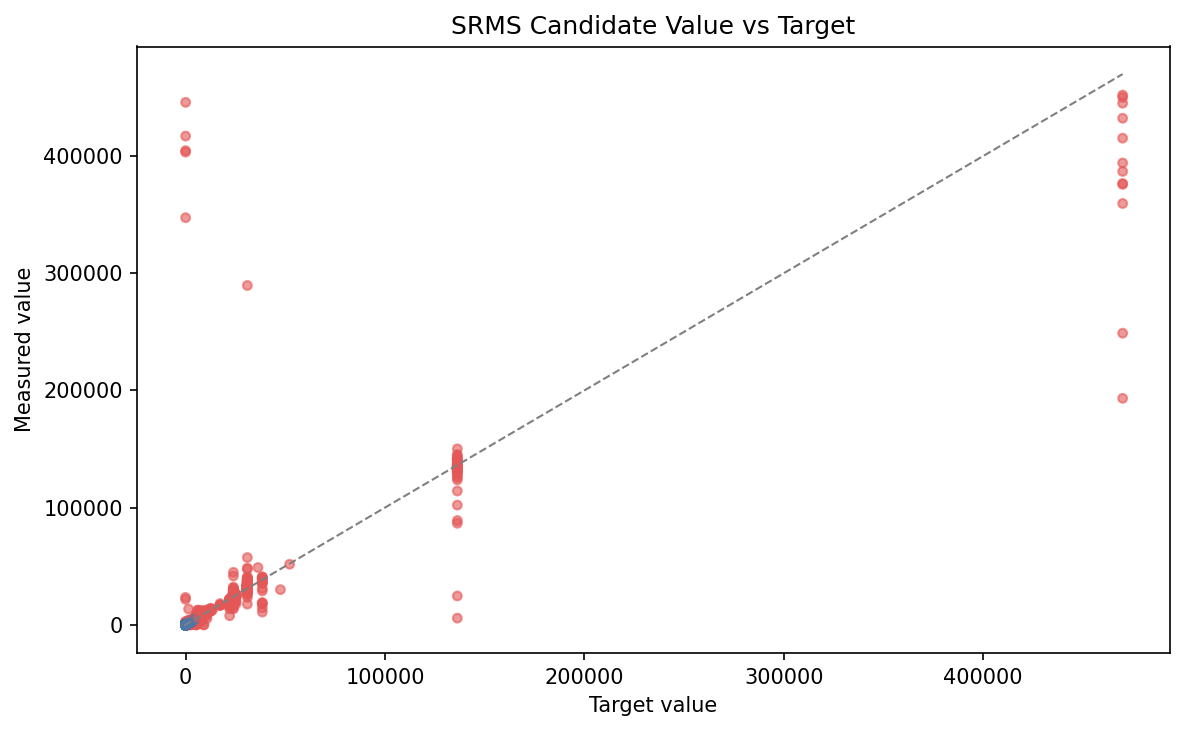

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results['TargetValue'], results['Value'], c=np.where(results['IForestAnomaly'], '#E45756', '#4C78A8'), alpha=0.6, s=18)
diagonal_min = min(results['TargetValue'].min(), results['Value'].min())
diagonal_max = max(results['TargetValue'].max(), results['Value'].max())
ax.plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], color='gray', linestyle='--', linewidth=1)
ax.set_title('SRMS Candidate Value vs Target')
ax.set_xlabel('Target value')
ax.set_ylabel('Measured value')
plt.tight_layout()
plt.show()


### SRMS Candidate Deviation Over Time

This plot shows how deviation percent changes over time and highlights model-detected anomalies. It helps reveal drift or sudden unusual behaviour.

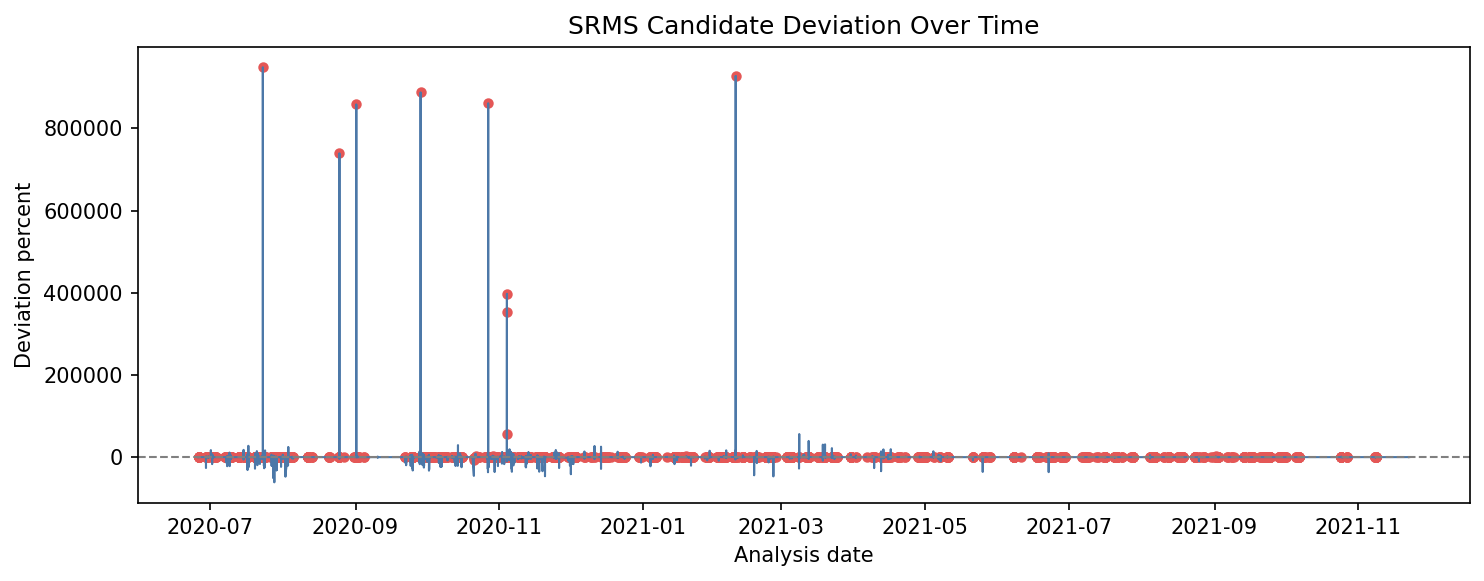

In [11]:
ordered = results.sort_values('AnalysisDate')
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ordered['AnalysisDate'], ordered['DeviationPct'], color='#4C78A8', linewidth=1)
anomalies = ordered[ordered['IForestAnomaly']]
ax.scatter(anomalies['AnalysisDate'], anomalies['DeviationPct'], color='#E45756', s=16)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('SRMS Candidate Deviation Over Time')
ax.set_xlabel('Analysis date')
ax.set_ylabel('Deviation percent')
plt.tight_layout()
plt.show()


### SRMS Candidate Risk Distribution

This chart summarises how many SRMS candidate results fall into Low, Medium, and High risk categories.

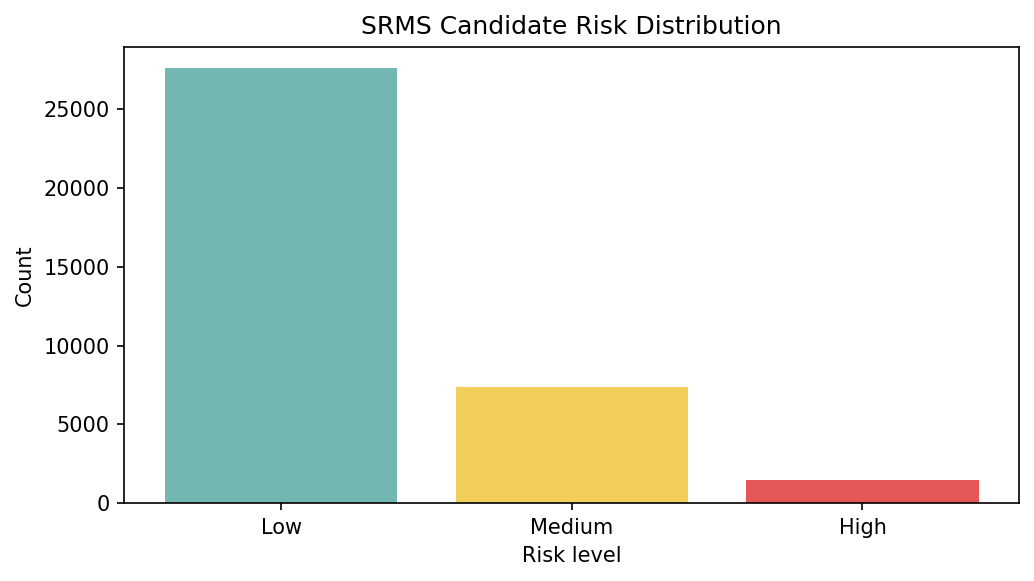

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(risk_summary['RiskLevel'].astype(str), risk_summary['Count'], color=['#72B7B2', '#F2CF5B', '#E45756'])
ax.set_title('SRMS Candidate Risk Distribution')
ax.set_xlabel('Risk level')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


### Top 10 SRMS Candidate Codes by Anomaly Rate

This chart shows which reference-material codes have the highest proportion of anomalies in the extracted subset.

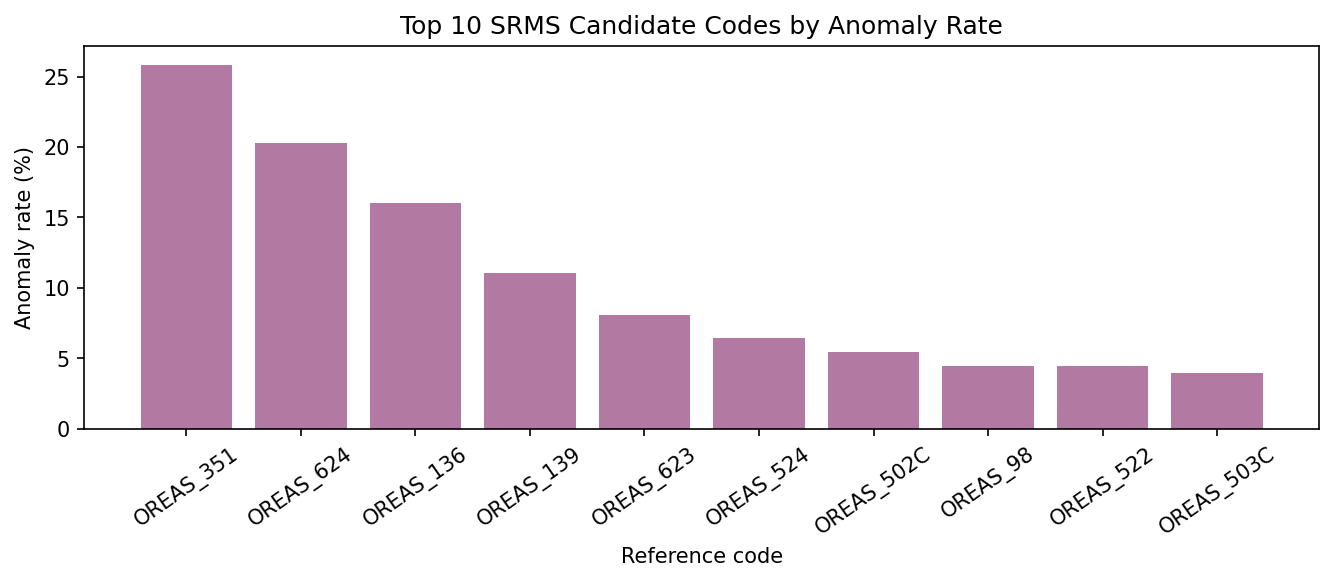

In [13]:
anomaly_rate = results.groupby('SRMSStandardCode')['IForestAnomaly'].mean().sort_values(ascending=False).head(10) * 100
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(anomaly_rate.index, anomaly_rate.values, color='#B279A2')
ax.set_title('Top 10 SRMS Candidate Codes by Anomaly Rate')
ax.set_xlabel('Reference code')
ax.set_ylabel('Anomaly rate (%)')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


### SRMS Candidate Deviation Percent Distribution

This histogram shows the overall distribution of deviation percent across the extracted SRMS candidate subset.

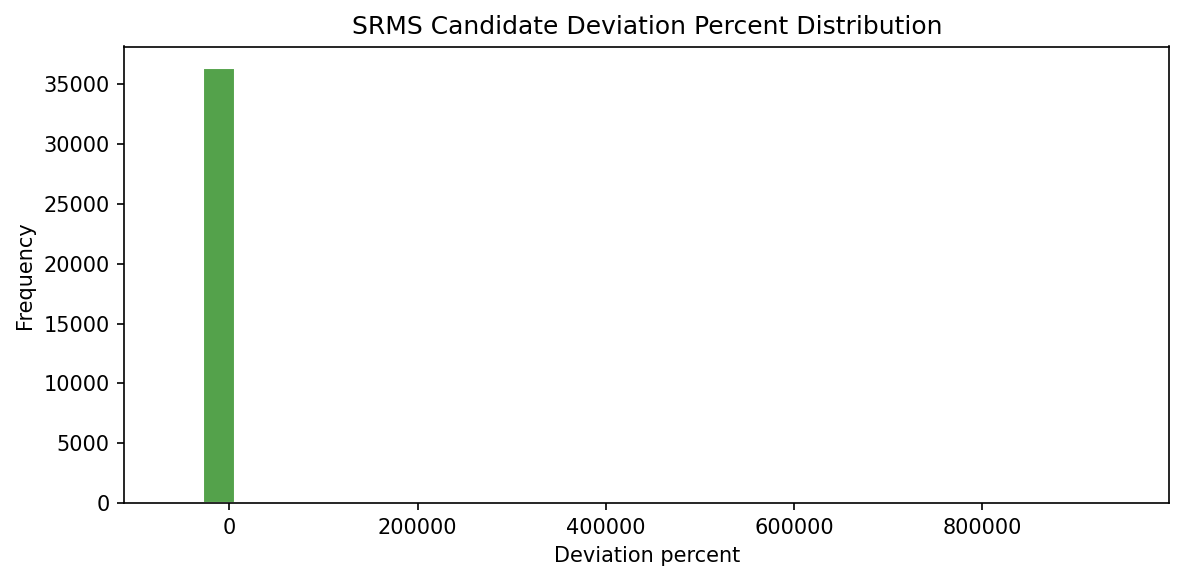

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(results['DeviationPct'], bins=30, color='#54A24B', edgecolor='white')
ax.set_title('SRMS Candidate Deviation Percent Distribution')
ax.set_xlabel('Deviation percent')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


### Top 10 High-Risk SRMS Candidate Results

This chart highlights the highest-priority results for review in the current SRMS candidate subset.

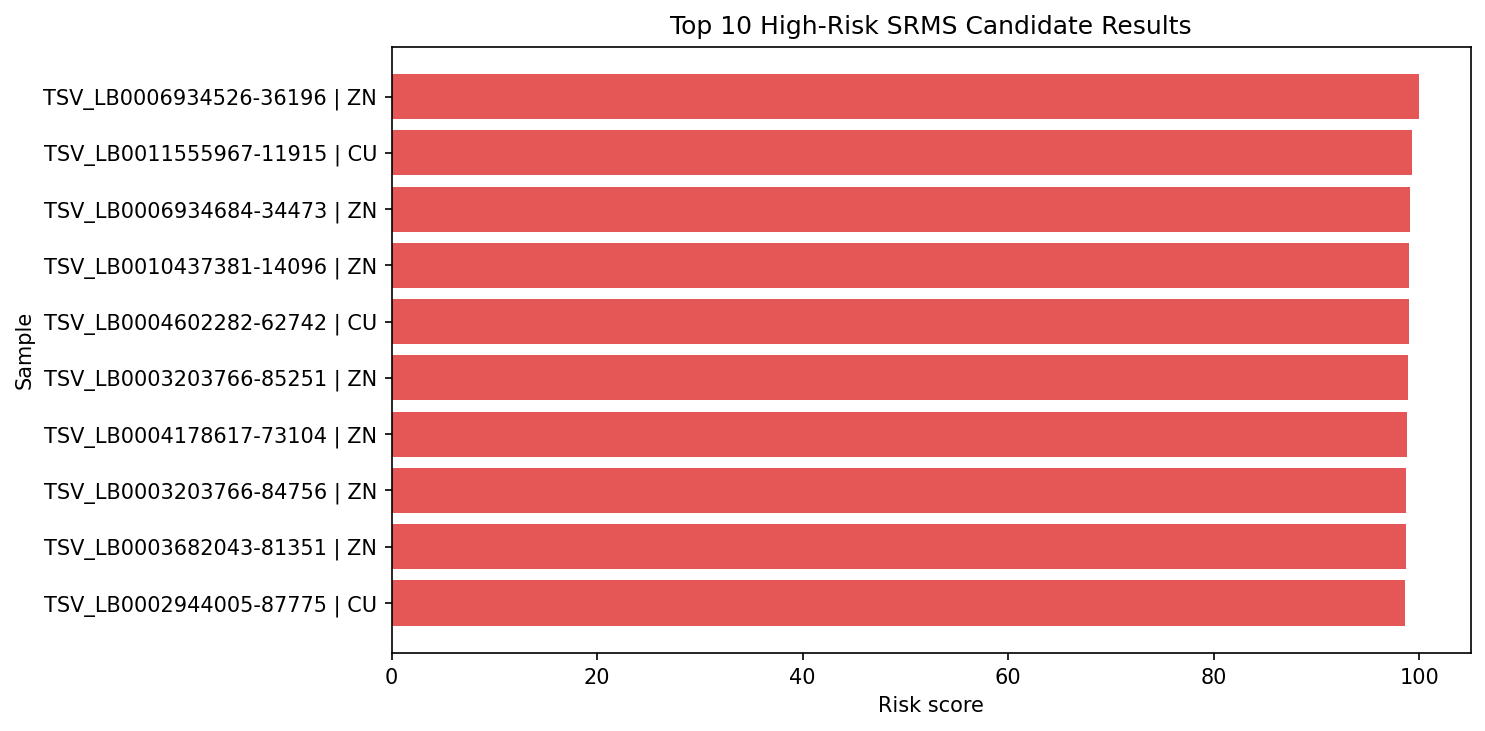

In [15]:
top_risk = results.sort_values('RiskScore', ascending=False).head(10)
labels = top_risk['SampleID'] + ' | ' + top_risk['Analyte']
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels.iloc[::-1], top_risk['RiskScore'].iloc[::-1], color='#E45756')
ax.set_title('Top 10 High-Risk SRMS Candidate Results')
ax.set_xlabel('Risk score')
ax.set_ylabel('Sample')
plt.tight_layout()
plt.show()


## 10. Saved outputs

This notebook saves:
- `srms_candidate_anomaly_results.csv`
- `srms_candidate_summary.csv`
- PNG chart files in the `srms_outputs` folder

These outputs can support reporting, further model refinement, and discussions with Datamine about whether the SRMS candidate extract is a suitable baseline.


In [16]:
results.to_csv(RESULTS_CSV, index=False)
risk_summary.to_csv(SUMMARY_CSV, index=False)

print('Saved files:')
print(RESULTS_CSV)
print(SUMMARY_CSV)
for image_path in sorted(OUTPUT_DIR.glob('*.png')):
    print(image_path)


Saved files:
/Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp/srms_candidate_anomaly_results.csv
/Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp/srms_candidate_summary.csv
/Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp/srms_outputs/srms_value_vs_target.png
/Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp/srms_outputs/srms_deviation_over_time.png
/Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp/srms_outputs/srms_risk_distribution.png
/Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp/srms_outputs/srms_top_codes_anomaly_rate.png
/Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp/srms_outputs/srms_deviation_histogram.png
/Users/linhlinh/Documents/New project/IFn735 Project/qc_anomaly_mvp/srms_outputs/srms_top_high_risk.png


## Limitations

This notebook has several important limitations that should be made clear when sharing it with Datamine:

- The analysed subset is **real data**, but it is not a fully confirmed SRMS-labelled dataset.
- SRMS records are inferred through a candidate extraction rule rather than a direct SRMS field.
- The machine learning method used here, **Isolation Forest**, is unsupervised and does not use human-validated anomaly labels.
- The notebook should therefore be interpreted as an **MVP for SRMS candidate anomaly detection**, not as final SRMS-specific validation.
- Any future subtype fields provided by Datamine would allow this workflow to be refined and made more accurate.


## Next Steps

The next step is to refine this MVP using additional clarification and data from Datamine.

In particular:
- Datamine may provide further subtype information or additional QC data related to **control**, **matrix spike**, and **SRMS/CRM-style materials**.
- Each team member can prepare focused questions for Datamine about how specific QC material types should be interpreted.
- If subtype-labelled records become available, this notebook can be updated to move from an **SRMS candidate subset** toward a more confidently identified SRMS workflow.
- Future improvements may also include stronger explainability, cross-batch analysis, validation against reviewed anomaly examples, and more user-facing report outputs.


## 11. Report interpretation

This notebook provides an **MVP workflow for SRMS candidate anomaly detection using the real ResultSet export**. Because explicit SRMS labels are not present in the source file, the analysis is based on a carefully extracted subset of reference-material standard records.

The workflow shows that:
- real QC data can be used directly
- a practical SRMS candidate subset can be extracted from the available export
- rule-based logic and machine learning can be combined
- anomaly and risk outputs can be generated in a reviewable form
- the results can be presented through tables, charts, and exported files

This means the notebook is suitable as an MVP because it already demonstrates the core user journey: real data goes in, anomaly assessment comes out. At the same time, it remains important to note that this is still an SRMS candidate workflow rather than a fully subtype-confirmed SRMS validation model.
